In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import os
from typing import Dict
import pickle
from scipy.stats import linregress


def set_default_plot_style():
    plt.style.use("default")  # start clean

    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.2
    plt.rcParams["grid.linestyle"] = "-"
    plt.rcParams["grid.color"] = "gray"

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    plt.rcParams["axes.linewidth"] = 1.2

    plt.rcParams["legend.frameon"] = False

    plt.rcParams["font.size"] = 23
    plt.rcParams["axes.labelsize"] = 30
    plt.rcParams["legend.fontsize"] = 18

    # plt.rcParams["font.size"] = 18
    # plt.rcParams["axes.labelsize"] = 24
    # plt.rcParams["legend.fontsize"] = 12

    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Computer Modern Roman']

# Call once at the top of your script
set_default_plot_style()


In [2]:
# Helpful funcs
def log_b(x, b):
    return np.log(x) / np.log(b)


In [3]:
# [round(0.2536 + i *0.0005, ndigits=6) for i in range(0, 6)]

In [4]:
L_vals = [20000]
epsilon_prime_c = 0.25375
epsilon_prime_vals = sorted(list(set([round(epsilon_prime_c + 0.0003 * i, ndigits = 6) for i in range(-2,3)] + [round(0.2536 + i *0.00005, ndigits=6) for i in range(0, 6)])))

time_prefact = 100

num_initial_conds = 4000
num_init_conds_offset = 0
initial_state_prob = 0.5

a_vals = [1/2]

time_step = 2000

cmap = plt.colormaps.get_cmap("Oranges").resampled(len(epsilon_prime_vals) + 5)

read_external_drive = True
write_external_drive = read_external_drive and True
local_data_parent_folder = "data"
second_data_parent_folder = "/Volumes/ExternalData/stavskya_mc/data"
if read_external_drive:
    data_parent_folder = "/Volumes/ExternalData/stavskya_mc/data"
    if write_external_drive:
        local_data_parent_folder = "/Volumes/ExternalData/stavskya_mc/data"
        second_data_parent_folder ="data"
else:
    data_parent_folder = local_data_parent_folder


# If first time

In [ ]:


collected_rhos = {}
collected_rho_stds = {}
counts = []
for L_val in L_vals:
    print(f"L_val: {L_val}")

    T_f = L_val*time_prefact
    collected_rhos[L_val] = {}
    collected_rho_stds[L_val] = {}

    for a_val in a_vals:
        print(f"L_val: {L_val} | a: {a_val}")
        a_val_name = f"{a_val}".replace(".", "p")

        collected_rhos[L_val][a_val] = {}
        collected_rho_stds[L_val][a_val] = {}

        for epsilon_prime in epsilon_prime_vals:
            print(f"L_val: {L_val} | a: {a_val} | epsilon: {epsilon_prime}")
            epsilon_val_name = f"{epsilon_prime}".replace(".", "p")

            current_rhos = np.array([[0.0 for _ in range(L_val * time_prefact // time_step)] for _ in range(num_initial_conds)])
            count = 0
            for init_cond in range(1, num_initial_conds+1):
                sample_filepath_name = os.path.join(data_parent_folder, f"time_rand_n/rho_per_time/IC1/L{L_val}/a{a_val_name}/epsilon{epsilon_val_name}/IC1_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}_sample{init_cond}.csv")
                    
                try:
                    df = pd.read_csv(sample_filepath_name)

                    current_rhos[count] = df.rho
                    count += 1
                except Exception as e:
                    print(e)
                    print(sample_filepath_name)
            current_rhos = current_rhos[0:count]
            counts.append(count)
            
            collected_rhos[L_val][a_val][epsilon_prime] = np.mean(current_rhos.T, axis=1)
            collected_rho_stds[L_val][a_val][epsilon_prime] = np.std(current_rhos.T, axis=1)

            pickle_path = os.path.join(local_data_parent_folder, f"time_rand_n/rho_per_time/IC{num_initial_conds}/L{L_val}/a{a_val_name}/epsilon{epsilon_val_name}/IC{num_initial_conds}_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}")
            second_pickle_path = os.path.join(second_data_parent_folder, f"time_rand_n/rho_per_time/IC{num_initial_conds}/L{L_val}/a{a_val_name}/epsilon{epsilon_val_name}/IC{num_initial_conds}_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}")
                                                                 
            dir_path = os.path.dirname(pickle_path)
            os.makedirs(dir_path, exist_ok=True)
            
            with open(pickle_path + "mean.pickle", "wb") as f:
                pickle.dump(collected_rhos[L_val][a_val][epsilon_prime], f)
            with open(pickle_path + "stds.pickle", "wb") as f:
                pickle.dump(collected_rho_stds[L_val][a_val][epsilon_prime], f)

            try:
                dir_path = os.path.dirname(second_pickle_path)
                os.makedirs(dir_path, exist_ok=True)
                with open(second_pickle_path + "mean.pickle", "wb") as f:
                    pickle.dump(collected_rhos[L_val][a_val][epsilon_prime], f)
                with open(second_pickle_path + "stds.pickle", "wb") as f:
                    pickle.dump(collected_rho_stds[L_val][a_val][epsilon_prime], f)
            except Exception as E:
                print(E)

print(min(counts))

L_val: 20000
L_val: 20000 | a: 0.5
L_val: 20000 | a: 0.5 | epsilon: 0.25315
[Errno 2] No such file or directory: '/Volumes/ExternalData/stavskya_mc/data/time_rand_n/rho_per_time/IC1/L20000/a0p5/epsilon0p25315/IC1_L20000_epsilon0p25315_timepref100_timestep2000_sample1.csv'
/Volumes/ExternalData/stavskya_mc/data/time_rand_n/rho_per_time/IC1/L20000/a0p5/epsilon0p25315/IC1_L20000_epsilon0p25315_timepref100_timestep2000_sample1.csv
[Errno 2] No such file or directory: '/Volumes/ExternalData/stavskya_mc/data/time_rand_n/rho_per_time/IC1/L20000/a0p5/epsilon0p25315/IC1_L20000_epsilon0p25315_timepref100_timestep2000_sample2.csv'
/Volumes/ExternalData/stavskya_mc/data/time_rand_n/rho_per_time/IC1/L20000/a0p5/epsilon0p25315/IC1_L20000_epsilon0p25315_timepref100_timestep2000_sample2.csv
[Errno 2] No such file or directory: '/Volumes/ExternalData/stavskya_mc/data/time_rand_n/rho_per_time/IC1/L20000/a0p5/epsilon0p25315/IC1_L20000_epsilon0p25315_timepref100_timestep2000_sample3.csv'
/Volumes/External

PermissionError: [Errno 13] Permission denied: '/Volumes/ExternalData'

In [ ]:
print(sample_filepath_name)

/Volumes/ExternalData/stavskya_mc/data/time_rand_n/rho_per_time/IC1/L20000/a0p5/epsilon0p2542/IC1_L20000_epsilon0p2542_timepref100_timestep2000_sample4000.csv


## If you have already processed and saved the data as pickled

In [5]:

collected_rhos = {}
collected_rho_stds = {}

for L_val in L_vals:
    print(f"L_val: {L_val}")

    T_f = L_val*time_prefact
    collected_rhos[L_val] = {}
    collected_rho_stds[L_val] = {}

    for a_val in a_vals:
        print(f"L_val: {L_val} | a: {a_val}")
        a_val_name = f"{a_val}".replace(".", "p")

        collected_rhos[L_val][a_val] = {}
        collected_rho_stds[L_val][a_val] = {}
        for epsilon_prime in epsilon_prime_vals:
            epsilon_val_name = f"{epsilon_prime}".replace(".", "p")
            pickle_path = os.path.join(local_data_parent_folder, f"time_rand_n/rho_per_time/IC{num_initial_conds}/L{L_val}/a{a_val_name}/epsilon{epsilon_val_name}/IC{num_initial_conds}_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}")
            
            try:
                with open(pickle_path + "mean.pickle", "rb") as f:
                    collected_rhos[L_val][a_val][epsilon_prime] = pickle.load(f)
                with open(pickle_path + "stds.pickle", "rb") as f:
                    collected_rho_stds[L_val][a_val][epsilon_prime] = pickle.load(f)
            except Exception as e:
                print(e, "\n Loading from local source")
                second_pickle_path = os.path.join(second_data_parent_folder, f"time_rand_n/rho_per_time/IC{num_initial_conds}/L{L_val}/a{a_val_name}/epsilon{epsilon_val_name}/IC{num_initial_conds}_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}")

                with open(second_pickle_path + "mean.pickle", "rb") as f:
                    collected_rhos[L_val][a_val][epsilon_prime] = pickle.load(f)
                with open(second_pickle_path + "stds.pickle", "rb") as f:
                    collected_rho_stds[L_val][a_val][epsilon_prime] = pickle.load(f)
                print("\t sucsess")
                

L_val: 20000
L_val: 20000 | a: 0.5
[Errno 2] No such file or directory: '/Volumes/ExternalData/stavskya_mc/data/time_rand_n/rho_per_time/IC4000/L20000/a0p5/epsilon0p25315/IC4000_L20000_epsilon0p25315_timepref100_timestep2000mean.pickle' 
 Loading from local source
	 sucsess
[Errno 2] No such file or directory: '/Volumes/ExternalData/stavskya_mc/data/time_rand_n/rho_per_time/IC4000/L20000/a0p5/epsilon0p25345/IC4000_L20000_epsilon0p25345_timepref100_timestep2000mean.pickle' 
 Loading from local source
	 sucsess
[Errno 2] No such file or directory: '/Volumes/ExternalData/stavskya_mc/data/time_rand_n/rho_per_time/IC4000/L20000/a0p5/epsilon0p2536/IC4000_L20000_epsilon0p2536_timepref100_timestep2000mean.pickle' 
 Loading from local source
	 sucsess
[Errno 2] No such file or directory: '/Volumes/ExternalData/stavskya_mc/data/time_rand_n/rho_per_time/IC4000/L20000/a0p5/epsilon0p25365/IC4000_L20000_epsilon0p25365_timepref100_timestep2000mean.pickle' 
 Loading from local source
	 sucsess
[Errno 

In [9]:
collected_rhos[L_vals[0]][a_vals[0]][epsilon_prime_vals[0]] == collected_rhos[L_vals[0]][a_vals[0]][epsilon_prime_vals[1]]

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False])

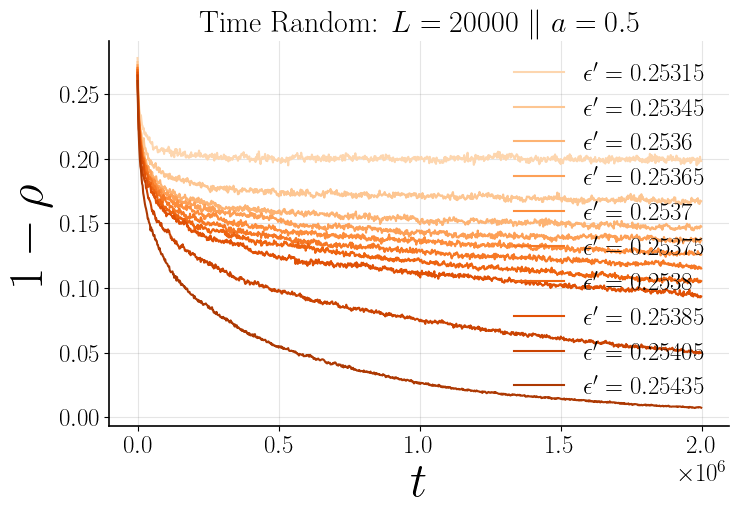

In [6]:
plt.figure(figsize=(8,5))

for j, L in enumerate(L_vals):
    for a_val in a_vals:
        a_val_name = f"{a_val}".replace(".", "p")
        for i, epsilon_val in enumerate(epsilon_prime_vals):
            c = cmap(i+3)
            time_vals = [i * time_step for i in range(0, L*time_prefact // time_step)]
            plt.plot(
                time_vals[:], 
                1-collected_rhos[L][a_val][epsilon_val][:], 
                label = fr"$\epsilon' = {epsilon_val}$",
                # fmt='--',  
                # markersize=3,
                # marker = "o",
                # capsize=3,
                c=c
                )
        # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
        plt.title(fr"Time Random: $L = {L}$ $\|$ $a = {a_val}$")
        plt.xlabel(r"$t$")
        plt.ylabel(r"$1 - \rho$")
        plt.legend()

        plt.show()


/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_2954/1855011351.py:9: RuntimeWarning: divide by zero encountered in log
  log_time_vals = np.log(np.array(time_vals))


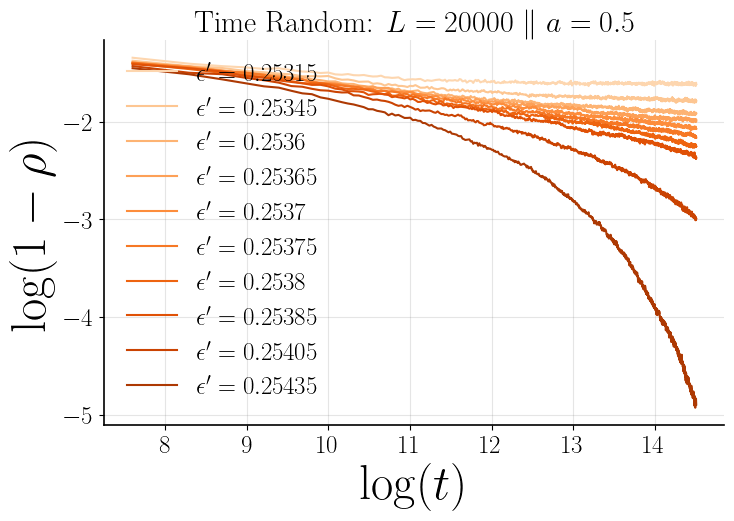

In [7]:
plt.figure(figsize=(8,5))

for j, L in enumerate(L_vals):
    for a_val in a_vals:
        a_val_name = f"{a_val}".replace(".", "p")
        for i, epsilon_val in enumerate(epsilon_prime_vals):
            c = cmap(i+3)
            time_vals = [i * time_step for i in range(0, L*time_prefact // time_step)]
            log_time_vals = np.log(np.array(time_vals))
            data_to_plot = np.log(1-collected_rhos[L][a_val][epsilon_val])
            plt.plot(
                log_time_vals[:], 
                data_to_plot[:], 
                label = fr"$\epsilon' = {round(epsilon_val, ndigits=7)}$",
                # fmt='--',  
                # markersize=3,
                # marker = "o",
                # capsize=3,
                c=c
                )
        # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
        plt.title(fr"Time Random: $L = {L}$ $\|$ $a = {a_val}$")
        plt.xlabel(r"$\log(t)$")
        plt.ylabel(r"$\log(1 - \rho)$")
        plt.legend()

        plt.show()


/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_30853/80866257.py:17: RuntimeWarning: divide by zero encountered in divide
  np.log((1/np.array(time_vals))[0:-1]),


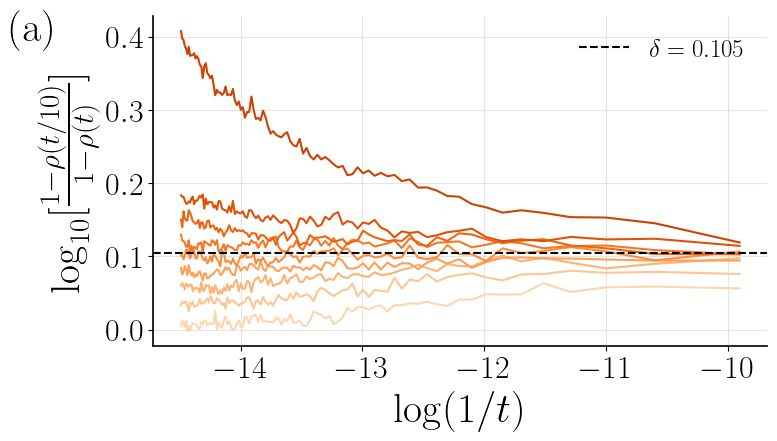

In [ ]:
b = 10
delta_guess = 0.105
fig=plt.figure(figsize=(8,5))
for j, L in enumerate(L_vals):
    for a_val in a_vals:
        a_val_name = f"{a_val}".replace(".", "p")
        for i, epsilon_val in enumerate(epsilon_prime_vals):
            if i == len(epsilon_prime_vals) - 1:
                continue
            c = cmap(i+3)
            time_vals = [i * b*time_step for i in range(0, L*time_prefact // (b * time_step))]
            data_to_plot = 1-collected_rhos[L][a_val][epsilon_val]
            data_to_plot_numerator = np.array([data_to_plot[(t//(b*time_step)) -1] for t in time_vals])
            data_to_plot_denomenator = np.array([data_to_plot[(t//time_step)-1] for t in time_vals])
            data_to_plot = log_b(data_to_plot_numerator[:len(data_to_plot_denomenator)]/data_to_plot_denomenator, 10)
            plt.plot(
                np.log((1/np.array(time_vals))), 
                data_to_plot, 
                # label = fr"$\epsilon' = {epsilon_val}$",
                # fmt='--',  
                # markersize=3,
                # marker = "o",
                # capsize=3,
                c=c
                )
        
        
        plt.axhline(delta_guess, c = 'k', label=fr"$\delta = {delta_guess}$", linestyle ="--")
        # plt.title(fr"Time Random: $L = {L}$ $\|$ $a = {a_val}$")
        plt.text(0.01, 0.85, "(a)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)
        plt.xlabel(r"$\log(1/t)$")
        plt.ylabel(r"$\log_{10}[\frac{1-\rho(t/10)}{1-\rho(t)}]$")
        plt.legend()
        # plt.xlim((np.log(0.000005), np.log(0.0005)))
        # plt.ylim((0.01, 0.25))
        plt.tight_layout()
        plt.savefig(f"figs/time_random/broad/broadstav_determining_ac_delta.png")
        plt.show()

In [38]:
0.105 * 2.25

0.23625

Beta: 0.23625


/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_30853/1574440435.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


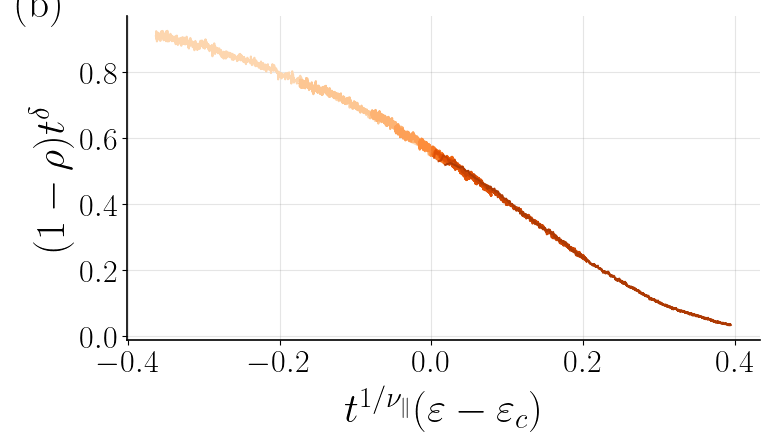

In [8]:
delta_guess = 0.105
guess_nu_par = 2.25
epsilon_c = 0.253725
print(f"Beta: {delta_guess*guess_nu_par}")
for j, L in enumerate(L_vals):
    plt.figure(figsize=(8,5))
    for i, epsilon_val in enumerate(epsilon_prime_vals):
        if epsilon_val == epsilon_c:
            continue
        c = cmap(i+3)
        time_vals = np.array([i * time_step for i in range(0, L*time_prefact // time_step)])
        orig_data = 1-collected_rhos[L][a_val][epsilon_val]
        plt.plot(
            (time_vals**(1/guess_nu_par)*(epsilon_val - epsilon_c))[1:], 
            (orig_data * time_vals ** delta_guess)[1:], 
            # label = fr"$\varepsilon' = {epsilon_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
    
    # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
    # plt.title(fr"Time Random $a = {a_val}$: $L = {L}$ $\|$ $\delta = {delta_guess}$ $\|$ $\nu_{{\|}} = {guess_nu_par}$")
    plt.text(0.02, 0.85, "(b)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)
    plt.xlabel(r"$t^{1/\nu_{\|}}(\varepsilon - \varepsilon_c)$")
    plt.ylabel(r"$(1 - \rho)t^\delta$")
    plt.legend()
    # plt.xlim(0.0003, 0.16)
    # plt.ylim(0.3, 1.1)

    plt.tight_layout()
    plt.savefig(f"figs/time_random/broad/broadstav_determining_nupar.png")
    plt.show()

/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_97856/3620055008.py:25: RuntimeWarning: divide by zero encountered in divide
  np.log((1 / np.array(time_vals_a))[0:-1]),


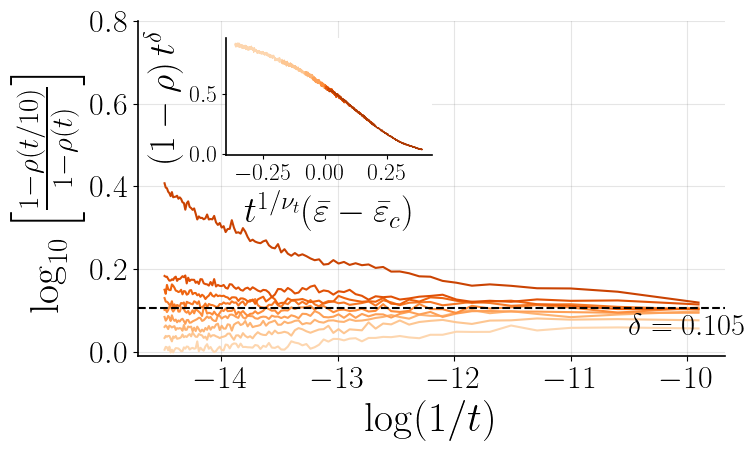

In [8]:
b = 10
delta_guess = 0.105
guess_nu_par = 2.25
epsilon_c = 0.253725

fig, ax = plt.subplots(figsize=(8, 5))

# --- Inset axes (plot b content) ---
ax_inset = ax.inset_axes([0.15, 0.6, 0.35, 0.35])

for j, L in enumerate(L_vals):
    for a_val in a_vals:
        for i, epsilon_val in enumerate(epsilon_prime_vals):

            c = cmap(i + 3)

            # --- Main plot (a) ---
            if i != len(epsilon_prime_vals) - 1:
                time_vals_a = [i * b * time_step for i in range(0, L * time_prefact // (b * time_step))]
                data_to_plot = 1 - collected_rhos[L][a_val][epsilon_val]
                data_numerator = np.array([data_to_plot[(t // (b * time_step))] for t in time_vals_a])
                data_denominator = np.array([data_to_plot[t // time_step] for t in time_vals_a])
                data_ratio = log_b(data_numerator[:len(data_denominator)] / data_denominator, 10)
                ax.plot(
                    np.log((1 / np.array(time_vals_a))[0:-1]),
                    data_ratio[1:],
                    c=c
                )

            # --- Inset (plot b content) ---
            if epsilon_val == epsilon_c:
                continue
            time_vals_b = np.array([i * time_step for i in range(0, L * time_prefact // time_step)])
            orig_data = 1 - collected_rhos[L][a_val][epsilon_val]
            ax_inset.plot(
                (time_vals_b ** (1 / guess_nu_par) * (epsilon_val - epsilon_c))[1:],
                (orig_data * time_vals_b ** delta_guess)[1:],
                c=c,
                lw=0.9
            )

ax.axhline(delta_guess, c='k', label=fr"$\delta = {delta_guess}$", linestyle="--")
ax.text(-10.5, 0.04, rf"$\delta={delta_guess}$", fontsize=plt.rcParams["axes.labelsize"]-8)
ax.set_xlabel(r"$\log(1/t)$")
ax.set_ylabel(r"$\log_{10}\left[\frac{1-\rho(t/10)}{1-\rho(t)}\right]$")
# ax.legend(loc="lower right")
ax.set_ylim(-0.01, 0.8)

# --- Inset formatting ---
ax_inset.set_xlabel(r"$t^{1/\nu_t}(\bar{\varepsilon} - \bar{\varepsilon}_c)$", fontsize=26)
ax_inset.set_ylabel(r"$(1 - \rho)\,t^\delta$", fontsize=26)
ax_inset.tick_params(labelbottom=True, labelleft=True, length=3, labelsize=17)
ax_inset.grid(False)
ax_inset.set_facecolor(fig.get_facecolor())

fig.tight_layout()
plt.savefig(f"figs/time_random/broad/broadstav_determining_ac_delta_nupar.png")
plt.show()

In [30]:
print(guess_nu_par*delta_guess)

0.23318749999999996


> Looks like
- $\varepsilon_c \approx 0.253725 \pm 0.000005$
- $\nu_{\|} \approx 2.25 \pm 0.05$
- $\beta \approx 0.236 \pm 0.005$

In [22]:
print(guess_nu_par*delta_guess)
print(np.sqrt((0.01*guess_nu_par)**2 + (0.05*delta_guess)**2))

0.24725
0.022255617268456068


# By hand collpase
The expected form (near the crit pt) is

$(1-\rho)t^{\beta/\nu_{\|}} \sim g(t^{-z})$